# HOG + HSV Color + Random Forest Training Notebook

This notebook shows the complete flow for a HOG + HSV color + Random Forest classifier:

1. Explore the dataset distribution and sample images.
2. Show the feature pipeline: original image -> grayscale/resize -> HOG visualization + HSV color histogram.
3. Extract HOG descriptors and inspect the dataset shapes.
4. Tune Random Forest hyperparameters with Optuna.
5. Evaluate the trained model with feature importance, confusion matrix, and prediction examples.


## 0. Imports


In [100]:
from __future__ import annotations

from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from joblib import Parallel, delayed
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from skimage import exposure
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm


## 1. Path and dataset helpers


In [101]:
def resolve_data_dir() -> Path:
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "data"
        if (candidate / "train").is_dir() and (candidate / "test").is_dir():
            return candidate
    raise FileNotFoundError("Could not find data/train and data/test")


def collect_paths(split_dir: Path) -> tuple[list[Path], np.ndarray, list[str]]:
    labels = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    if not labels:
        raise RuntimeError(f"No class folders found in {split_dir}")

    paths: list[Path] = []
    y: list[str] = []
    for label in labels:
        for path in sorted((split_dir / label).glob("*.*")):
            if path.is_file():
                paths.append(path)
                y.append(label)

    if not paths:
        raise RuntimeError(f"No images found in {split_dir}")

    return paths, np.array(y), labels


## 2. Display helper


In [102]:
def show_table(df: pd.DataFrame) -> None:
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


## 3. Image and HOG helpers


In [103]:
def load_image_steps(path: Path, image_size: tuple[int, int] | None = None):
    if image_size is None:
        image_size = IMAGE_SIZE

    image = imread(path)
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    if image.ndim == 3:
        gray = rgb2gray(image)
    else:
        gray = image.astype(np.float32)
        if gray.max() > 1:
            gray = gray / 255.0

    resized = resize(gray, image_size, anti_aliasing=True)
    return image, gray, resized


def to_uint8_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)
    if image.ndim == 3 and image.shape[-1] == 4:
        image = image[..., :3]

    rgb = image.astype(np.float32)
    if rgb.max() <= 1.0:
        rgb = rgb * 255.0
    return np.clip(rgb, 0, 255).astype(np.uint8)


def resize_rgb_image(image: np.ndarray, image_size: tuple[int, int]) -> np.ndarray:
    rgb = to_uint8_rgb(image)
    height, width = image_size
    return cv2.resize(rgb, (width, height), interpolation=cv2.INTER_AREA)


def enhance_hog_image(hog_image: np.ndarray) -> np.ndarray:
    image = np.asarray(hog_image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.maximum(image, 0.0)

    if float(image.max()) <= float(image.min()):
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    active = image[image > 0]
    if active.size == 0:
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    low = float(np.percentile(active, 5.0))
    high = float(np.percentile(active, 99.5))
    if high <= low:
        low = 0.0
        high = float(active.max())

    image = np.clip((image - low) / (high - low + 1e-8), 0.0, 1.0)
    image = np.power(image, 0.32)
    image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    image_u8 = cv2.dilate(image_u8, np.ones((2, 2), dtype=np.uint8), iterations=1)

    color_bgr = cv2.applyColorMap(image_u8, cv2.COLORMAP_TURBO)
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
    canvas = np.full((*image_u8.shape, 3), 246, dtype=np.uint8)
    mask = image_u8 > 10
    alpha = (image_u8.astype(np.float32) / 255.0)[..., None]
    blended = canvas.astype(np.float32) * (1.0 - alpha) + color_rgb.astype(np.float32) * alpha
    canvas[mask] = blended[mask].astype(np.uint8)
    return canvas


def extract_hog_visual(gray_resized: np.ndarray, hog_params: dict):
    descriptors, hog_image = hog(gray_resized, visualize=True, **hog_params)
    hog_image = enhance_hog_image(hog_image)
    return descriptors, hog_image


def extract_hsv_histogram(
    image: np.ndarray,
    image_size: tuple[int, int],
    hsv_bins: tuple[int, int, int],
) -> np.ndarray:
    rgb_resized = resize_rgb_image(image, image_size)
    hsv = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2HSV)
    h_bins, s_bins, v_bins = hsv_bins

    hist_h = cv2.calcHist([hsv], [0], None, [h_bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [s_bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [v_bins], [0, 256]).flatten()

    color_feature = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    color_feature /= color_feature.sum() + 1e-8
    return color_feature


def extract_combined_feature(
    image: np.ndarray,
    gray_resized: np.ndarray,
    hog_params: dict,
    hsv_bins: tuple[int, int, int],
    image_size: tuple[int, int],
) -> np.ndarray:
    hog_feature = hog(gray_resized, **hog_params).astype(np.float32)
    color_feature = extract_hsv_histogram(image, image_size, hsv_bins)
    return np.concatenate([hog_feature, color_feature])


def split_combined_feature(feature: np.ndarray, hog_dim: int, color_dim: int):
    return feature[:hog_dim], feature[hog_dim:hog_dim + color_dim]


def choose_representative_sample(
    paths: list[Path],
    labels: np.ndarray,
    preferred_label: str | None = None,
) -> tuple[Path, str]:
    labels = np.asarray(labels)
    if preferred_label is not None and preferred_label in set(labels):
        idx = int(np.where(labels == preferred_label)[0][0])
        return paths[idx], str(labels[idx])
    return paths[0], str(labels[0])


## 4. Feature extraction helper


In [104]:
def compute_features(
    paths: list[Path],
    labels: np.ndarray,
    image_size: tuple[int, int],
    hog_params: dict,
    hsv_bins: tuple[int, int, int],
    cache_file: Path | None,
    n_jobs: int,
) -> tuple[np.ndarray, np.ndarray]:
    if cache_file is not None and cache_file.exists():
        with np.load(cache_file) as data:
            X_cached = data["X"]
            y_cached = data["y"]
        if len(y_cached) == len(labels):
            return X_cached, y_cached
        print(
            f"Cache {cache_file.name} has {len(y_cached)} samples, "
            f"but this run needs {len(labels)} samples. Recomputing the cache."
        )

    def extract(path: Path) -> np.ndarray | None:
        try:
            image, _, gray_resized = load_image_steps(path, image_size)
            return extract_combined_feature(image, gray_resized, hog_params, hsv_bins, image_size)
        except Exception:
            return None

    desc = f"HOG+HSV {cache_file.stem}" if cache_file is not None else "HOG+HSV"
    features = Parallel(n_jobs=n_jobs)(
        delayed(extract)(p) for p in tqdm(paths, desc=desc, total=len(paths))
    )

    kept_feats: list[np.ndarray] = []
    kept_labels: list[str] = []
    skipped = 0
    for feat, label in zip(features, labels):
        if feat is None:
            skipped += 1
            continue
        kept_feats.append(feat)
        kept_labels.append(label)

    if not kept_feats:
        raise RuntimeError("No features extracted; check input images.")

    X = np.vstack(kept_feats)
    y = np.array(kept_labels)

    if cache_file is not None:
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cache_file, X=X, y=y)

    if skipped:
        print(f"Skipped {skipped} unreadable files.")

    return X, y


## 5. EDA plotting helpers


In [105]:
def plot_dataset_distribution(split_labels: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for split_name, labels in split_labels.items():
        counts = pd.Series(labels, name="class").value_counts().sort_index()
        for class_name, count in counts.items():
            rows.append({"Split": split_name, "Class": class_name, "Count": int(count)})

    df = pd.DataFrame(rows)
    table = df.pivot_table(index="Class", columns="Split", values="Count", fill_value=0).astype(int)
    show_table(table)

    ax = table.plot(kind="bar", figsize=(11, 5), width=0.82)
    ax.set_title("Image count by class and dataset split")
    ax.set_xlabel("Traffic sign class")
    ax.set_ylabel("Image count")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(title="Split")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    return table


In [106]:
def plot_class_samples(
    paths: list[Path],
    labels: np.ndarray,
    max_per_class: int = 4,
    title: str = "Sample images by class",
) -> None:
    labels = np.asarray(labels)
    class_names = sorted(set(labels))
    n_rows = len(class_names)
    n_cols = max_per_class
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.7 * n_rows))
    axes = np.atleast_2d(axes)

    for row, class_name in enumerate(class_names):
        class_paths = [p for p, y in zip(paths, labels) if y == class_name][:max_per_class]
        for col in range(n_cols):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(class_paths):
                image, _, _ = load_image_steps(class_paths[col])
                ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
                ax.set_title(class_name if col == 0 else "", fontsize=10)

    fig.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


## 6. HOG pipeline plotting helper


In [107]:
def plot_preprocessing_and_hog(sample_path: Path, sample_label: str) -> np.ndarray:
    image, gray, resized = load_image_steps(sample_path)
    hog_descriptors, hog_image = extract_hog_visual(resized, HOG_PARAMS)
    color_descriptors = extract_hsv_histogram(image, IMAGE_SIZE, HSV_HIST_BINS)
    combined = np.concatenate([hog_descriptors.astype(np.float32), color_descriptors])

    fig, axes = plt.subplots(1, 5, figsize=(19, 4))
    axes[0].imshow(image, cmap="gray" if image.ndim == 2 else None)
    axes[0].set_title(f"Original image\n{sample_label}")
    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale")
    axes[2].imshow(resized, cmap="gray")
    axes[2].set_title(f"Resize {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}")
    axes[3].imshow(hog_image)
    axes[3].set_title(f"HOG\n{len(hog_descriptors):,} descriptors")

    bin_labels = [f"H{i + 1}" for i in range(HSV_HIST_BINS[0])] + [f"S{i + 1}" for i in range(HSV_HIST_BINS[1])] + [f"V{i + 1}" for i in range(HSV_HIST_BINS[2])]
    axes[4].bar(np.arange(len(color_descriptors)), color_descriptors, color="#2a9d8f")
    axes[4].set_title(f"HSV color histogram\n{len(color_descriptors):,} descriptors")
    axes[4].set_xticks(np.arange(len(color_descriptors))[::4])
    axes[4].set_xticklabels(bin_labels[::4], rotation=60, ha="right", fontsize=8)
    axes[4].grid(axis="y", linestyle="--", alpha=0.3)

    for ax in axes[:4]:
        ax.axis("off")
    fig.suptitle("Feature extraction: HOG shape descriptors + HSV color descriptors", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()
    return combined


## 7. Feature summary helper


In [108]:
def print_feature_overview() -> pd.DataFrame:
    color_dim = sum(HSV_HIST_BINS)
    hog_dim = X_train.shape[1] - color_dim
    df = pd.DataFrame(
        [
            {"Split": "Train", "Samples": len(X_train), "HOG descriptors": hog_dim, "HSV descriptors": color_dim, "Total features": X_train.shape[1]},
            {"Split": "Validation", "Samples": len(X_val), "HOG descriptors": hog_dim, "HSV descriptors": color_dim, "Total features": X_val.shape[1]},
            {"Split": "Test", "Samples": len(X_test), "HOG descriptors": hog_dim, "HSV descriptors": color_dim, "Total features": X_test.shape[1]},
        ]
    )
    show_table(df)
    return df


## 8. Optuna and model plotting helpers


In [109]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "n_estimators": 10,
        "max_depth": trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": SEED,
        "warm_start": True,
        "n_jobs": 1,
    }
    clf = RandomForestClassifier(**params)
    acc = 0.0
    for n_estimators in ESTIMATOR_STEPS:
        clf.set_params(n_estimators=n_estimators)
        clf.fit(X_train, y_train_enc)
        acc = accuracy_score(y_val_enc, clf.predict(X_val))
        trial.report(acc, n_estimators)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("model", clf)
    return acc


In [110]:
def plot_optuna_progress(study: optuna.Study) -> pd.DataFrame:
    rows = []
    for trial in study.trials:
        if trial.value is None:
            continue
        rows.append(
            {
                "trial": trial.number,
                "value": trial.value,
                "state": str(trial.state).split(".")[-1],
                **trial.params,
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        print("No completed Optuna trials to plot yet.")
        return df

    df = df.sort_values("trial")
    df["best_so_far"] = df["value"].cummax()
    show_table(df.tail(10))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df["trial"], df["value"], marker="o", linewidth=1.2, label="Trial validation accuracy")
    ax.plot(df["trial"], df["best_so_far"], marker="s", linewidth=2.0, label="Best so far")
    ax.set_title("Optuna hyperparameter search progress")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Validation accuracy")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Best validation accuracy:", study.best_value)
    print("Best parameters:", study.best_params)
    return df


In [111]:
def plot_feature_importance(model: RandomForestClassifier, top_n: int = 25) -> None:
    importances = getattr(model, "feature_importances_", None)
    if importances is None:
        print("This model does not expose feature_importances_.")
        return

    top_n = min(top_n, len(importances))
    idx = np.argsort(importances)[-top_n:]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(np.arange(top_n), importances[idx], color="#59a14f")
    ax.set_yticks(np.arange(top_n))
    ax.set_yticklabels([f"HOG[{i}]" for i in idx])
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_n} HOG features used by Random Forest")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Evaluation plotting helper


In [112]:
def plot_confusion_matrix_view(cm: np.ndarray, class_names: np.ndarray, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=35, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    threshold = cm.max() / 2 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "black"
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()


## 10. Prediction plotting helpers


In [113]:
def predict_one_image(model: RandomForestClassifier, label_encoder: LabelEncoder, path: Path):
    image, gray, resized = load_image_steps(path)
    _hog_descriptors, hog_image = extract_hog_visual(resized, HOG_PARAMS)
    feature = extract_combined_feature(image, resized, HOG_PARAMS, HSV_HIST_BINS, IMAGE_SIZE)
    X_one = feature.reshape(1, -1)
    pred_enc = model.predict(X_one)[0]
    pred_label = label_encoder.inverse_transform([pred_enc])[0]
    proba = model.predict_proba(X_one)[0] if hasattr(model, "predict_proba") else None
    return image, gray, resized, hog_image, pred_label, proba


In [114]:
def plot_prediction_grid(
    model: RandomForestClassifier,
    label_encoder: LabelEncoder,
    paths: list[Path],
    labels: np.ndarray,
    max_images: int = 10,
) -> None:
    labels = np.asarray(labels)
    selected: list[tuple[Path, str]] = []
    per_class = max(1, max_images // len(label_encoder.classes_))
    for class_name in label_encoder.classes_:
        class_paths = [(p, str(y)) for p, y in zip(paths, labels) if y == class_name][:per_class]
        selected.extend(class_paths)
    selected = selected[:max_images]

    if not selected:
        print("No test images are available for prediction examples.")
        return

    n_cols = min(5, len(selected))
    n_rows = int(np.ceil(len(selected) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.1 * n_cols, 3.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (path, true_label) in zip(axes, selected):
        image, _, _, _, pred_label, proba = predict_one_image(model, label_encoder, path)
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
        color = "#1b7837" if pred_label == true_label else "#b2182b"
        confidence = ""
        if proba is not None:
            confidence = f" ({proba.max():.2f})"
        ax.set_title(f"True: {true_label}\nPred: {pred_label}{confidence}", color=color, fontsize=9)
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    fig.suptitle("Prediction examples on the test set", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


In [115]:
def plot_single_prediction_pipeline(
    model: RandomForestClassifier,
    label_encoder: LabelEncoder,
    sample_path: Path,
    true_label: str,
) -> None:
    image, gray, resized, hog_image, pred_label, proba = predict_one_image(model, label_encoder, sample_path)

    fig, axes = plt.subplots(1, 5, figsize=(19, 4))
    axes[0].imshow(image, cmap="gray" if image.ndim == 2 else None)
    axes[0].set_title(f"Original image\nTrue: {true_label}")
    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale")
    axes[2].imshow(resized, cmap="gray")
    axes[2].set_title(f"Resize {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}")
    axes[3].imshow(hog_image)
    axes[3].set_title("HOG")

    if proba is not None:
        order = np.argsort(proba)[::-1]
        axes[4].barh(np.arange(len(order)), proba[order], color="#f28e2b")
        axes[4].set_yticks(np.arange(len(order)))
        axes[4].set_yticklabels(label_encoder.classes_[order])
        axes[4].invert_yaxis()
        axes[4].set_xlim(0, 1)
        axes[4].set_xlabel("Probability")
        axes[4].set_title(f"Pred: {pred_label}")
        axes[4].grid(axis="x", linestyle="--", alpha=0.3)
    else:
        axes[4].text(0.5, 0.5, f"Pred: {pred_label}", ha="center", va="center")
        axes[4].axis("off")

    for ax in axes[:4]:
        ax.axis("off")

    fig.suptitle("Prediction pipeline: image -> HOG + HSV -> Random Forest -> label", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


## 11. Experiment configuration


In [116]:
SEED = 42
IMAGE_SIZE = (128, 128)
FEATURE_EXTRACTOR_NAME = "HOG_HSV"
HSV_HIST_BINS = (16, 8, 8)
HOG_PARAMS = {
    "orientations": 9,
    "pixels_per_cell": (6, 6),
    "cells_per_block": (3, 3),
    "block_norm": "L2-Hys",
}
VAL_SIZE = 0.2
N_JOBS = 8
OPTUNA_TRIALS = 50
OPTUNA_JOBS = 4
RF_JOBS = 4
ESTIMATOR_STEPS = [50, 100, 150, 200]

DATA_DIR = resolve_data_dir()
MODELS_DIR = DATA_DIR.parent / "models"
CACHE_DIR = DATA_DIR.parent / "cache"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## 12. Load data and create train/validation/test splits


In [117]:
all_train_paths, all_train_labels, train_classes = collect_paths(DATA_DIR / "train")
test_paths, test_labels, test_classes = collect_paths(DATA_DIR / "test")

if set(train_classes) != set(test_classes):
    print("Warning: train/test class folders differ; using the union of labels.")
all_classes = sorted(set(train_classes) | set(test_classes))

train_paths, val_paths, y_train, y_val = train_test_split(
    all_train_paths,
    all_train_labels,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=all_train_labels,
)

print(f"DATA_DIR: {DATA_DIR}")
print(f"Classes: {all_classes}")
print(f"Original train set: {len(all_train_paths):,} images")
print(f"Training split: {len(train_paths):,} images")
print(f"Validation split: {len(val_paths):,} images")
print(f"Test split: {len(test_paths):,} images")


DATA_DIR: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data
Classes: ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
Original train set: 2,730 images
Training split: 2,184 images
Validation split: 546 images
Test split: 303 images


## 13. Explore dataset distribution


Split,Original train,Test,Train,Validation
Class,,,,
Cam,613,68,490,123
Chidan,567,63,454,113
Hieulenh,587,65,470,117
Nguyhiem,591,66,473,118
Phu,372,41,297,75


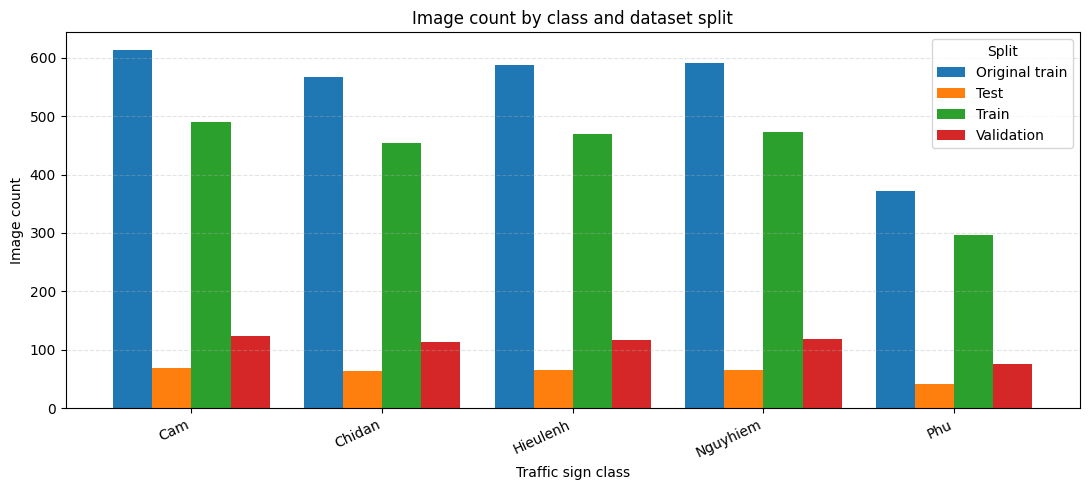

In [118]:
distribution_table = plot_dataset_distribution(
    {
        "Original train": all_train_labels,
        "Train": y_train,
        "Validation": y_val,
        "Test": test_labels,
    }
)


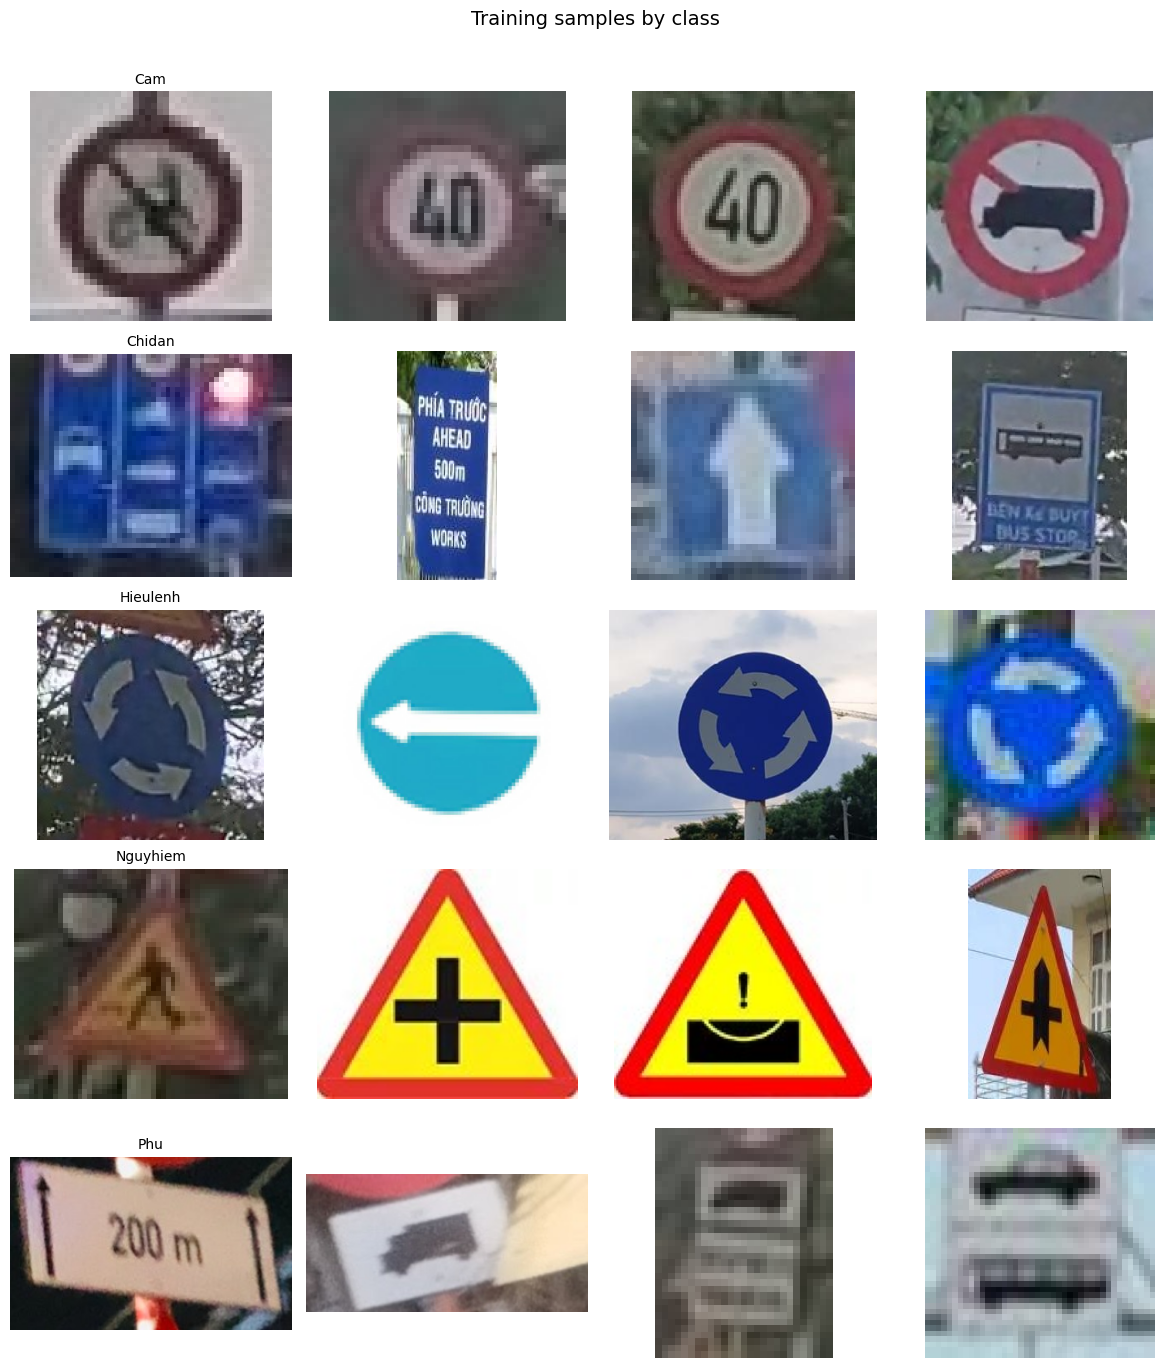

In [119]:
plot_class_samples(
    all_train_paths,
    all_train_labels,
    max_per_class=4,
    title="Training samples by class",
)


## 14. Visualize preprocessing and HOG


Sample image: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test\Nguyhiem\Nguyhiem_001.jpg


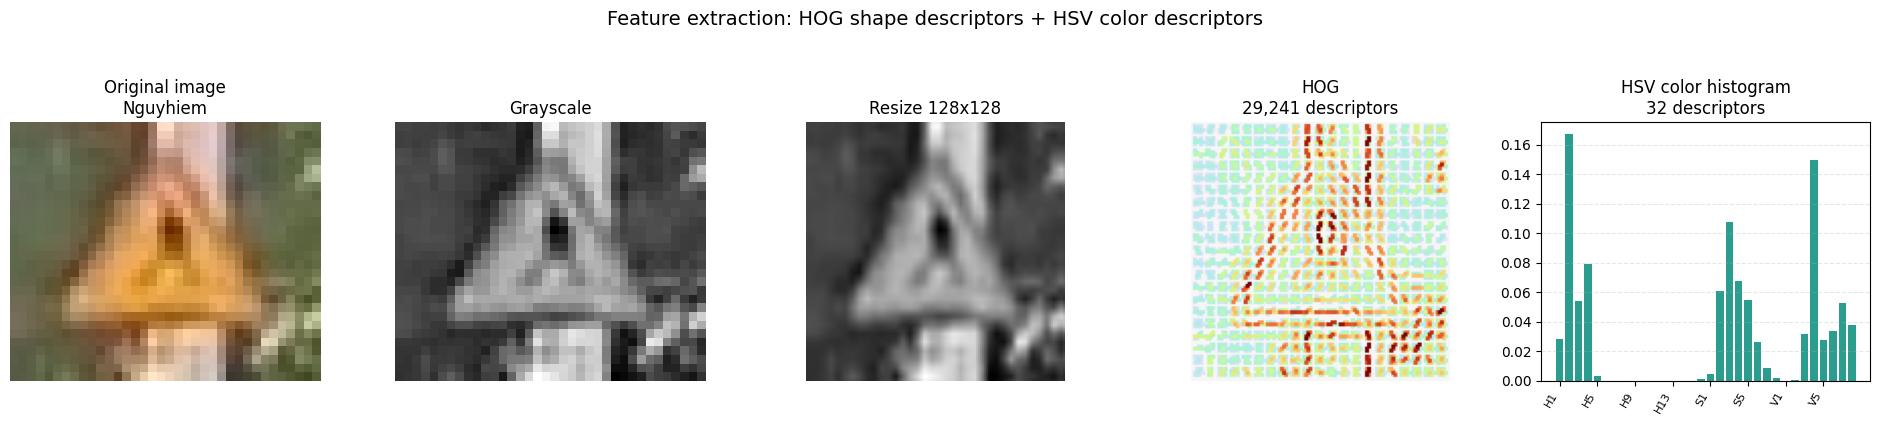

Combined feature count for one image: 29,273
HOG parameters: {'orientations': 9, 'pixels_per_cell': (6, 6), 'cells_per_block': (3, 3), 'block_norm': 'L2-Hys'}
HSV histogram bins: (16, 8, 8)


In [120]:
sample_path, sample_label = choose_representative_sample(
    test_paths,
    test_labels,
    preferred_label="Nguyhiem",
)
print("Sample image:", sample_path)
sample_combined_feature = plot_preprocessing_and_hog(sample_path, sample_label)
print(f"Combined feature count for one image: {sample_combined_feature.shape[0]:,}")
print("HOG parameters:", HOG_PARAMS)
print("HSV histogram bins:", HSV_HIST_BINS)


## 15. Extract HOG + HSV Color Features


In [121]:
cache_tag = (
    f"hog_hsv_rf_{HOG_PARAMS['pixels_per_cell'][0]}x{HOG_PARAMS['cells_per_block'][0]}_"
    f"hsv{HSV_HIST_BINS[0]}-{HSV_HIST_BINS[1]}-{HSV_HIST_BINS[2]}_"
    f"{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}_"
    f"val{int(VAL_SIZE * 100)}_seed{SEED}"
)
X_train, y_train = compute_features(
    train_paths, y_train, IMAGE_SIZE, HOG_PARAMS, HSV_HIST_BINS, CACHE_DIR / f"{cache_tag}_train.npz", N_JOBS
)
X_val, y_val = compute_features(
    val_paths, y_val, IMAGE_SIZE, HOG_PARAMS, HSV_HIST_BINS, CACHE_DIR / f"{cache_tag}_val.npz", N_JOBS
)
X_test, y_test = compute_features(
    test_paths, test_labels, IMAGE_SIZE, HOG_PARAMS, HSV_HIST_BINS, CACHE_DIR / f"{cache_tag}_test.npz", N_JOBS
)

le = LabelEncoder()
le.fit(all_classes)
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)


In [122]:
feature_overview = print_feature_overview()


,Split,Samples,HOG descriptors,HSV descriptors,Total features
0,Train,2184,29241,32,29273
1,Validation,546,29241,32,29273
2,Test,303,29241,32,29273


## 16. Tune Random Forest with Optuna


In [123]:
study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1),
    sampler=TPESampler(multivariate=True, seed=SEED),
)


e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\cs231-venv\Lib\site-packages\optuna\samplers\_tpe\sampler.py:319: ExperimentalWarning: ``multivariate`` option is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-05-17 13:06:29,442] A new study created in memory with name: no-name-4649c3d5-6805-4e4a-abb6-a34dfe497b0e


In [124]:
study.optimize(objective, n_trials=OPTUNA_TRIALS, n_jobs=OPTUNA_JOBS)


[I 2026-05-17 13:06:37,110] Trial 1 finished with value: 0.8351648351648352 and parameters: {'max_depth': 32, 'min_samples_split': 17, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 1 with value: 0.8351648351648352.
[I 2026-05-17 13:06:38,067] Trial 3 finished with value: 0.8498168498168498 and parameters: {'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 3 with value: 0.8498168498168498.
[I 2026-05-17 13:07:47,597] Trial 2 finished with value: 0.8864468864468864 and parameters: {'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8864468864468864.
[I 2026-05-17 13:07:51,510] Trial 0 finished with value: 0.8864468864468864 and parameters: {'max_depth': 37, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8864468864468864.
[I 2026-05-17 13:08:02,092] Trial 7 finished with value: 0.8553113553113553 

,trial,value,state,max_depth,min_samples_split,min_samples_leaf,max_features,best_so_far
40,40,0.860806,2,12,10,5,sqrt,0.912088
41,41,0.884615,2,14,9,6,sqrt,0.912088
42,42,0.838828,2,41,11,3,log2,0.912088
43,43,0.816850,2,33,19,5,log2,0.912088
44,44,0.873626,2,14,13,4,sqrt,0.912088
45,45,0.815018,2,15,16,10,log2,0.912088
46,46,0.873626,2,28,12,4,sqrt,0.912088
47,47,0.833333,2,23,9,4,log2,0.912088
48,48,0.864469,2,27,14,4,sqrt,0.912088
49,49,0.871795,2,24,13,4,sqrt,0.912088


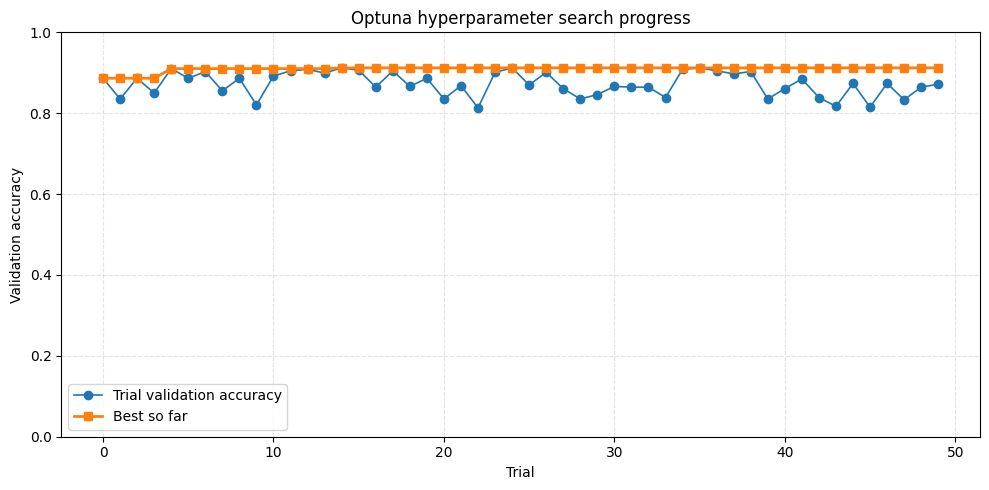

Best validation accuracy: 0.9120879120879121
Best parameters: {'max_depth': 45, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [125]:
optuna_trials_df = plot_optuna_progress(study)


## 17. Train final Random Forest


In [126]:
X_combined = np.vstack([X_train, X_val])
y_combined = np.concatenate([y_train_enc, y_val_enc])

best_params = dict(study.best_params)
best_params.update(
    {
        "n_estimators": max(ESTIMATOR_STEPS),
        "random_state": SEED,
        "warm_start": False,
        "n_jobs": RF_JOBS,
    }
)

best_clf = RandomForestClassifier(**best_params)
best_clf.fit(X_combined, y_combined)


RandomForestClassifier(max_depth=45, min_samples_leaf=3, min_samples_split=9,
                       n_estimators=200, n_jobs=4, random_state=42)

## 18. Evaluate the final model


In [127]:
y_pred_test = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test_enc, y_pred_test)
test_cm = confusion_matrix(y_test_enc, y_pred_test, labels=np.arange(len(le.classes_)))

print("Test accuracy:", test_accuracy)
print("\nClassification report:")
print(classification_report(y_test_enc, y_pred_test, target_names=le.classes_, zero_division=0))


Test accuracy: 0.976897689768977

Classification report:
              precision    recall  f1-score   support

         Cam       1.00      1.00      1.00        68
      Chidan       0.95      1.00      0.98        63
    Hieulenh       0.98      0.95      0.97        65
    Nguyhiem       0.97      0.97      0.97        66
         Phu       0.97      0.95      0.96        41

    accuracy                           0.98       303
   macro avg       0.98      0.97      0.98       303
weighted avg       0.98      0.98      0.98       303



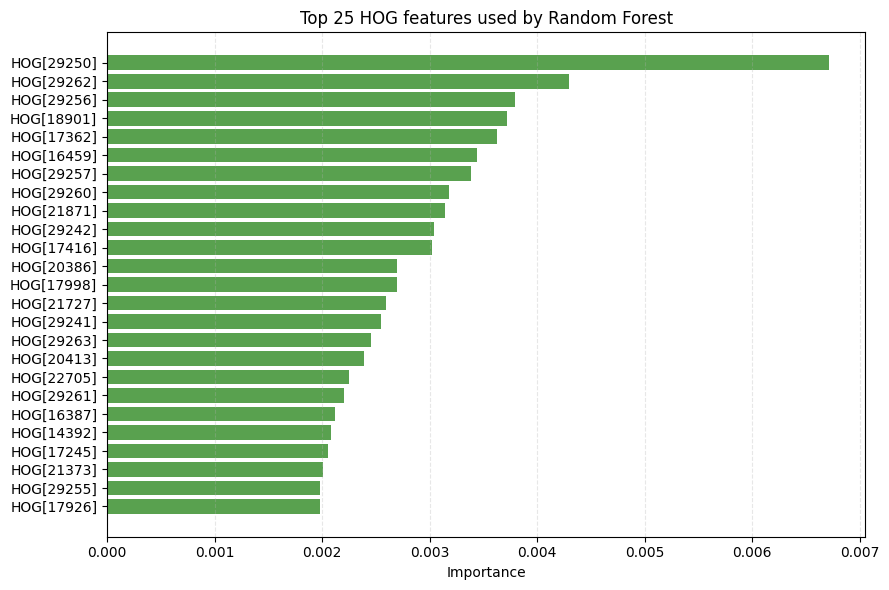

In [128]:
plot_feature_importance(best_clf, top_n=25)


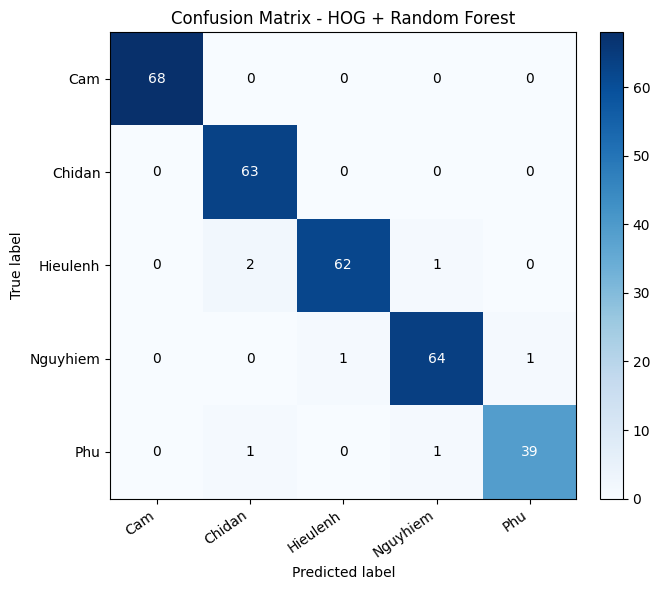

In [129]:
plot_confusion_matrix_view(test_cm, le.classes_, title="Confusion Matrix - HOG + Random Forest")


## 19. Error Analysis: All Wrong Predictions


In [130]:
def build_misclassification_df(
    paths: list[Path],
    X: np.ndarray,
    y_true_enc: np.ndarray,
    y_pred_enc: np.ndarray,
    label_encoder: LabelEncoder,
    model: RandomForestClassifier,
) -> pd.DataFrame:
    n_eval = min(len(X), len(y_true_enc), len(y_pred_enc), len(paths))
    if n_eval < len(y_true_enc) or n_eval < len(paths):
        print(
            "Warning: path count and evaluated sample count differ. "
            f"Using the first {n_eval} aligned samples for visualization."
        )

    true_labels = label_encoder.inverse_transform(y_true_enc[:n_eval])
    pred_labels = label_encoder.inverse_transform(y_pred_enc[:n_eval])

    confidence = [None] * n_eval
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X[:n_eval])
            confidence = [round(float(row.max()) * 100, 2) for row in proba]
        except Exception as exc:
            print("Could not compute predict_proba for error table:", exc)

    rows = []
    for i in range(n_eval):
        if true_labels[i] == pred_labels[i]:
            continue
        rows.append(
            {
                "index": i,
                "true_label": true_labels[i],
                "pred_label": pred_labels[i],
                "confidence_pct": confidence[i],
                "file_name": Path(paths[i]).name,
                "path": str(paths[i]),
            }
        )

    return pd.DataFrame(rows)


Wrong predictions: 7 / 303
Error rate: 2.31%


,index,true_label,pred_label,confidence_pct,file_name,path
0,132,Hieulenh,Chidan,27.49,Hieulenh_002.jpg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
1,179,Hieulenh,Nguyhiem,28.45,Hieulenh_049.jpg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
2,192,Hieulenh,Chidan,38.26,Hieulenh_062.jpg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
3,198,Nguyhiem,Hieulenh,32.28,Nguyhiem_003.png,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
4,220,Nguyhiem,Phu,27.30,Nguyhiem_025.jpg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
5,281,Phu,Chidan,32.73,Phu_020.jpg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
6,296,Phu,Nguyhiem,26.24,Phu_035.jpeg,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...


,true_label,pred_label,count,mean_confidence
0,Hieulenh,Chidan,2,32.875
4,Phu,Chidan,1,32.730
2,Nguyhiem,Hieulenh,1,32.280
1,Hieulenh,Nguyhiem,1,28.450
3,Nguyhiem,Phu,1,27.300
5,Phu,Nguyhiem,1,26.240


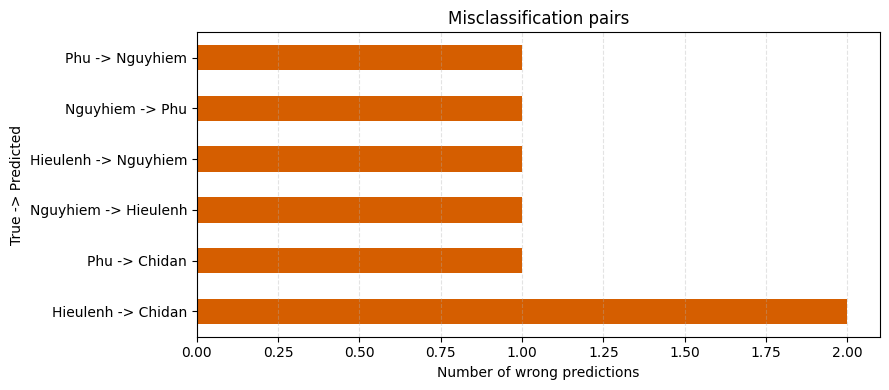

In [131]:
misclassified_df = build_misclassification_df(
    test_paths,
    X_test,
    y_test_enc,
    y_pred_test,
    le,
    best_clf,
)

print(f"Wrong predictions: {len(misclassified_df)} / {len(y_test_enc)}")
if len(y_test_enc) > 0:
    print(f"Error rate: {len(misclassified_df) / len(y_test_enc):.2%}")

display(misclassified_df)

if not misclassified_df.empty:
    error_pair_summary = (
        misclassified_df
        .groupby(["true_label", "pred_label"], as_index=False)
        .agg(count=("index", "count"), mean_confidence=("confidence_pct", "mean"))
        .sort_values(["count", "mean_confidence"], ascending=[False, False])
    )
    display(error_pair_summary)

    ax = error_pair_summary.assign(pair=lambda df: df["true_label"] + " -> " + df["pred_label"]).plot(
        kind="barh",
        x="pair",
        y="count",
        figsize=(9, max(4, 0.35 * len(error_pair_summary))),
        legend=False,
        color="#d55e00",
    )
    ax.set_title("Misclassification pairs")
    ax.set_xlabel("Number of wrong predictions")
    ax.set_ylabel("True -> Predicted")
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("No wrong predictions found on the current test set.")


In [132]:
def plot_all_misclassified_samples(
    misclassified: pd.DataFrame,
    samples_per_figure: int = 8,
    show_hog: bool = True,
) -> None:
    if misclassified.empty:
        print("No misclassified samples to visualize.")
        return

    samples_per_figure = max(1, samples_per_figure)
    total = len(misclassified)
    chunks = [misclassified.iloc[i:i + samples_per_figure] for i in range(0, total, samples_per_figure)]

    for page_idx, chunk in enumerate(chunks, start=1):
        if show_hog:
            fig, axes = plt.subplots(len(chunk), 2, figsize=(9, 3.0 * len(chunk)))
            axes = np.atleast_2d(axes)
        else:
            n_cols = 4
            n_rows = int(np.ceil(len(chunk) / n_cols))
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.5 * n_rows))
            axes = np.atleast_1d(axes).ravel()

        for local_idx, (_, row) in enumerate(chunk.iterrows()):
            image_path = Path(row["path"])
            image, _gray, resized = load_image_steps(image_path)
            _descriptors, hog_image = extract_hog_visual(resized, HOG_PARAMS)
            title = (
                f"#{int(row['index'])} | True: {row['true_label']} | Pred: {row['pred_label']}\n"
                f"{row['file_name']} | Conf: {row['confidence_pct']}%"
            )

            if show_hog:
                axes[local_idx, 0].imshow(image, cmap="gray" if image.ndim == 2 else None)
                axes[local_idx, 0].set_title(title, fontsize=10)
                axes[local_idx, 0].axis("off")

                axes[local_idx, 1].imshow(hog_image)
                axes[local_idx, 1].set_title("HOG visualization", fontsize=10)
                axes[local_idx, 1].axis("off")
            else:
                ax = axes[local_idx]
                ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
                ax.set_title(title, fontsize=9)
                ax.axis("off")

        if not show_hog:
            for ax in axes[len(chunk):]:
                ax.axis("off")

        fig.suptitle(f"Misclassified samples page {page_idx}/{len(chunks)}", y=1.01, fontsize=14)
        plt.tight_layout()
        plt.show()


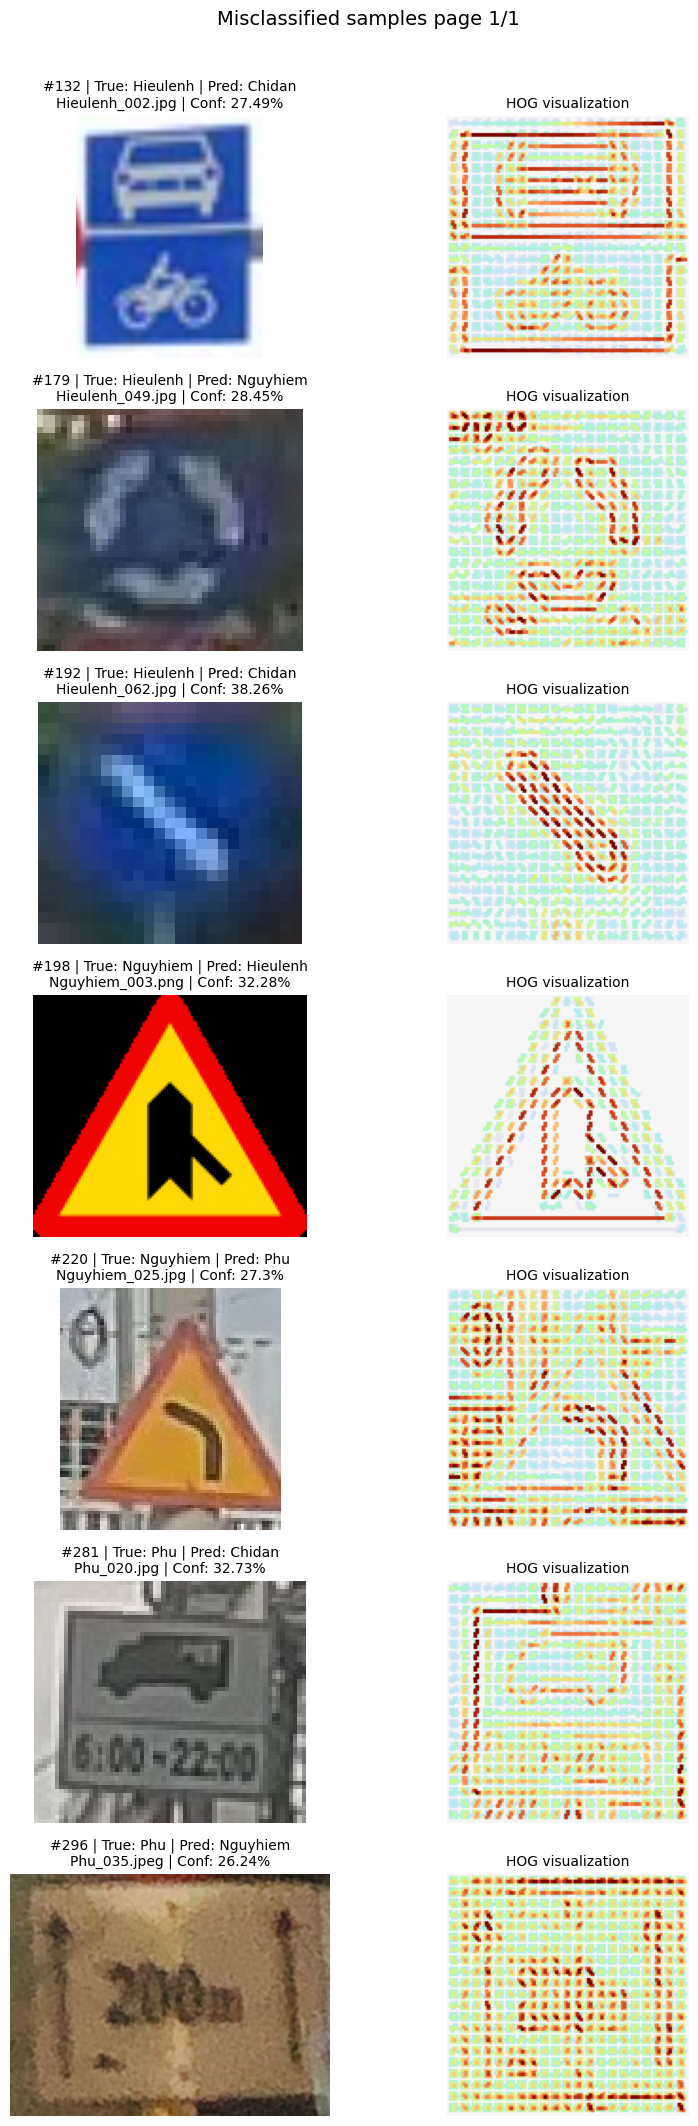

In [133]:
plot_all_misclassified_samples(
    misclassified_df,
    samples_per_figure=8,
    show_hog=True,
)


## 20. Visualize predictions


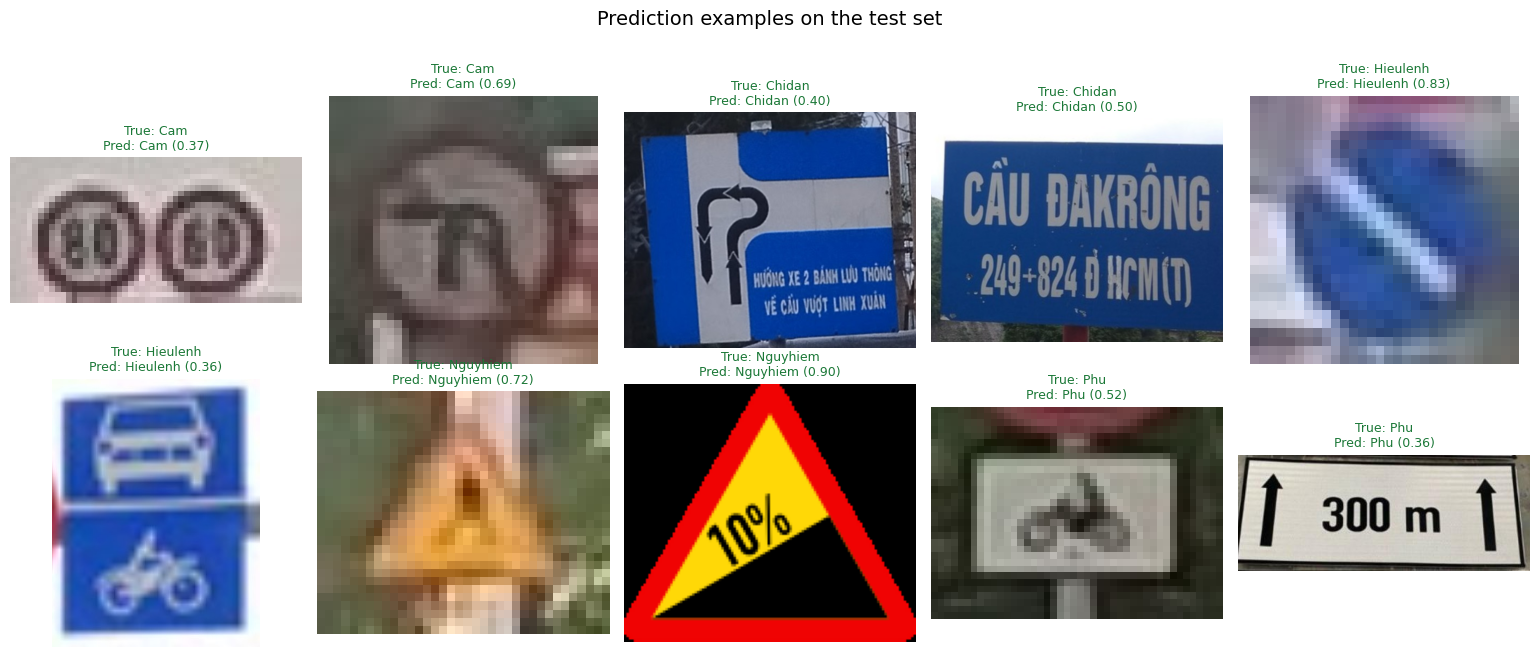

In [134]:
plot_prediction_grid(best_clf, le, test_paths, test_labels, max_images=10)


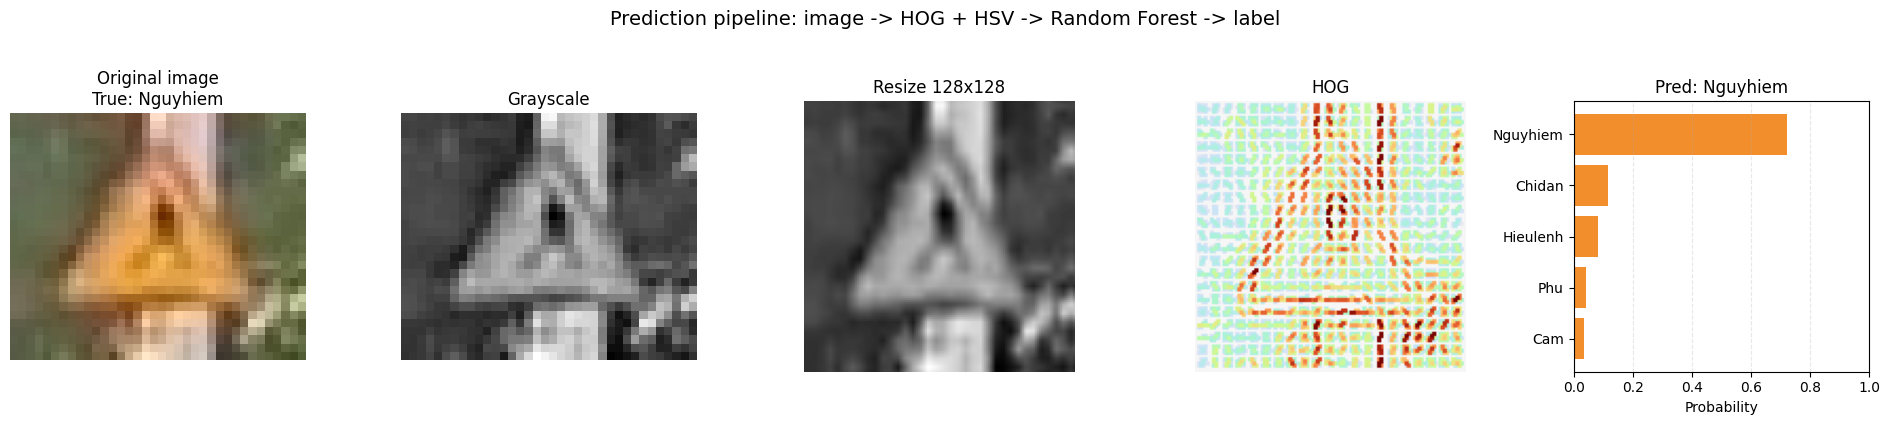

In [135]:
sample_path, sample_label = choose_representative_sample(
    test_paths,
    test_labels,
    preferred_label="Nguyhiem",
)
plot_single_prediction_pipeline(best_clf, le, sample_path, sample_label)


## 21. Save the trained model


In [136]:
model_path = MODELS_DIR / "HOG_RandomForest_6x3.joblib"
payload = {
    "model": best_clf,
    "label_encoder": le,
    "feature_extractor": FEATURE_EXTRACTOR_NAME,
    "hog_params": HOG_PARAMS,
    "hsv_hist_bins": HSV_HIST_BINS,
    "image_size": IMAGE_SIZE,
    "classes": list(le.classes_),
}
joblib.dump(payload, model_path)
print(f"Saved model to {model_path}")

Saved model to E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\models\HOG_RandomForest_6x3.joblib
